# Reinforcement Learning with FrozenLake

In this notebook, we implement a **Monte Carlo Reinforcement Learning (MC-RL) agent** to learn a Q-table.

We will:
- Understand the environment
- Implement an epsilon-greedy policy
- Learn action values (Q-table)
- Visualize learning progress

## Monte Carlo RL Concept

We focus on Monte Carlo RL because it is simpler and intuitive:
- The agent runs an episode from start to finish
- Only after the episode ends, it updates its estimates of how good each action was

This is **different** from Q-learning. It is conceptually slightly simpler. But has drawbacks. 

### Update Rule

For each state-action pair $(s, a)$ visited in an episode:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \cdot (G - Q(s,a))
$$

Where:
- $Q(s,a)$ = current estimate - this is your **expectation** of how good action $a$ is when you are in state $s$
- $G$ = total return from this state until episode end, or the sum of all future rewards (weighted). This is the **actual return**.
- $\alpha$ = learning rate


### Simple Explanation

- Imagine playing a game from start to finish without pausing.
- Only when the game ends do you reflect:  
  > “That move helped me win/lose points if I look at all that happened afterwards; next time I will do better but adjusting my expectations ($Q$) to look similar to what really happened ($G$).”
- Repeat many times → you get really good at choosing the right moves.


## Imports

In [1]:

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter


## Key Learning Parameters

These parameters control how the agent learns from experience.

### 1. Discount Factor γ

$$ G_t = R_t + \gamma R_{t+1} + \gamma^2 R_{t+2} + \cdots +  \gamma^{T-t-1}R_T$$

- γ = 0 → care only about now  
- γ ≈ 1 → care about long-term rewards

### 2. Learning Rate α

$$ Q(s,a) \leftarrow Q(s,a) + \alpha \cdot (G - Q(s,a)) $$

- High α → adjust quickly  
- Low α → stick to old knowledge and update only slightly

### 3. Exploration Rate ε

- Choose random action with probability ε, otherwise best known action.
- Balance exploring new actions vs exploiting known good actions.


In [2]:

alpha = 0.04
gamma = 0.95
epsilon = 0.05

## Reward Shaping: Teaching the Agent Better Behavior

In the original environment, the agent only gets:
- +1 for reaching the goal
- 0 for everything else

This makes learning **very slow**, because the agent gets almost no feedback. Reward shaping gives more frequent feedback to the user.

In [3]:
cost_of_living = -0.0001
punishment = -0.2

FrequentRewards = True


## 🌍 Environment: FrozenLake

We use a deterministic version (`is_slippery=False`) to make learning easier.

Goal:
- Reach the goal tile
- Avoid holes


In [4]:

env = gym.make("FrozenLake8x8-v1", is_slippery=False)

nEpisodes= 1000 # how many times you re-spawn the agent (number of lives)
T= 10000 # length of each episode (length of each life)



## Training Loop

We train over many episodes. Think of each episode as re-spawning your character (a new life). To do so we reset environment.

## What Does the Agent Actually Do?

At every step:

1. Look at current state
2. Choose action (random or best known, follow epsilon-greedy **policy**)
3. Move in the environment
4. Store what happened (Store trajectory)

After the episode:
- Look back and update all decisions (Update Q-values using returns)

### 🟡 Think Before Running

Before experimenting make a guess, based on the ideas above:
- What do you expect will happen if $\epsilon = 0$?
- What if $\epsilon = 1$?

Try changing it and observe:
- Does the agent still learn?
- Is it slower or faster?

In [5]:
Q = np.zeros([env.observation_space.n, env.action_space.n])
rewards_per_episode = []
q_values_at_intervals = [] # diagnostics and plotting

for episode in range(nEpisodes):
    state, prob = env.reset()

    # Initialize episode storage
    total_reward = 0
    episode_states = []
    episode_actions = []
    episode_rewards = []

    # run one episode (a trajectory)
    for step in range(T):

        # Epsilon-greedy policy
        if np.random.rand() < epsilon:
            action = np.random.choice(env.action_space.n)
        else:
            action = np.argmax(Q[state, :])

        new_state, reward, terminated, truncated, info = env.step(action)

        # Reward shaping
        if FrequentRewards:
            if terminated and reward == 0: # agent fall in a hole 
                reward += punishment
            reward += cost_of_living

        # Store trajectory
        episode_states.append(state)
        episode_actions.append(action)
        episode_rewards.append(reward)

        total_reward += reward
        state = new_state

        if terminated:
            if reward == 1 + cost_of_living:
                print(f"Episode {episode} success in {step+1} steps!")
            break

    rewards_per_episode.append(total_reward)

    # Monte Carlo return calculation
    G = 0
    for t in range(len(episode_states) - 1, -1, -1):
        state = episode_states[t]
        action = episode_actions[t]
        reward = episode_rewards[t]

        G = gamma * G + reward
        Q[state][action] += alpha * (G - Q[state][action])

    # Store snapshots of Q-table
    if (episode + 1) % (nEpisodes // 4) == 0:
        q_values_at_intervals.append(np.copy(Q))


Episode 436 success in 3553 steps!
Episode 439 success in 417 steps!
Episode 440 success in 253 steps!
Episode 441 success in 192 steps!
Episode 442 success in 534 steps!
Episode 443 success in 96 steps!
Episode 445 success in 20 steps!
Episode 446 success in 18 steps!
Episode 447 success in 18 steps!
Episode 448 success in 20 steps!
Episode 449 success in 18 steps!
Episode 450 success in 18 steps!
Episode 451 success in 19 steps!
Episode 452 success in 18 steps!
Episode 453 success in 18 steps!
Episode 454 success in 18 steps!
Episode 455 success in 18 steps!
Episode 456 success in 18 steps!
Episode 457 success in 18 steps!
Episode 458 success in 19 steps!
Episode 459 success in 98 steps!
Episode 460 success in 18 steps!
Episode 461 success in 20 steps!
Episode 462 success in 20 steps!
Episode 463 success in 18 steps!
Episode 464 success in 19 steps!
Episode 465 success in 19 steps!
Episode 466 success in 20 steps!
Episode 467 success in 18 steps!
Episode 468 success in 18 steps!
Epis


## Learning Curve

We plot Raw rewards and Smoothed rewards (moving average).


## What Should We Expect?

If learning works:
- Rewards should increase over time
- Variance should decrease

If not:
- The agent might be stuck exploring
- Or not learning from experience

🟡 Run the code below and look at the plot and decide: is learning happening?

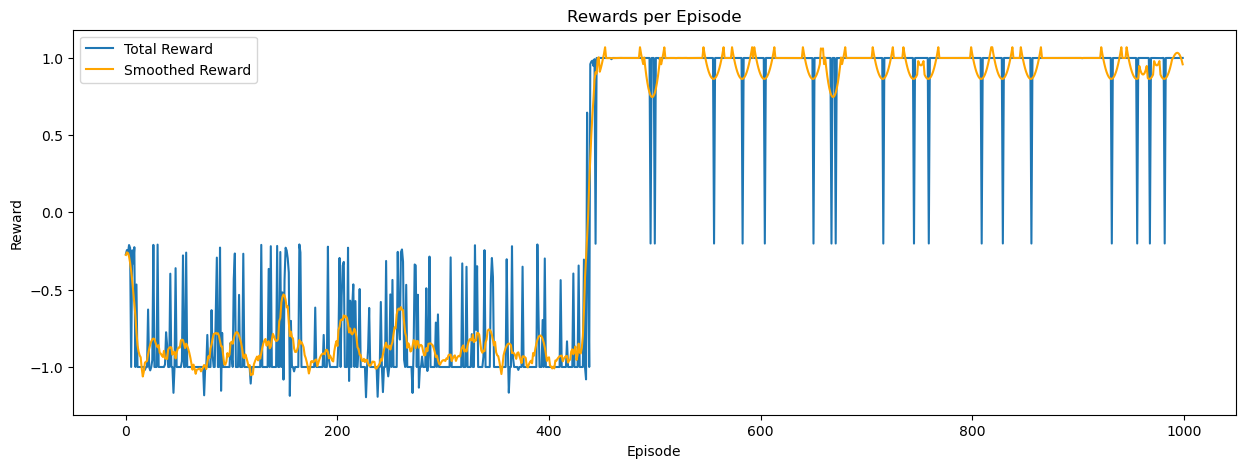

In [10]:

plt.figure(figsize=(15, 5))

plt.plot(rewards_per_episode, label='Total Reward')

moving_avg = savgol_filter(rewards_per_episode, 20, 3)
plt.plot(moving_avg, label='Smoothed Reward', color='orange')

plt.title("Rewards per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.show()


## 🟡 Answer these questions

- Do rewards increase over time?
- Is learning stable or noisy?
- Did reward shaping help?
- Is learning happening gradual or suddenly?
- What happens if you change the hyper-parameters, penalties or T (length of a life)? 

If not, what might be wrong?


## Q-Table Evolution

We visualize how the Q-values evolve over time.


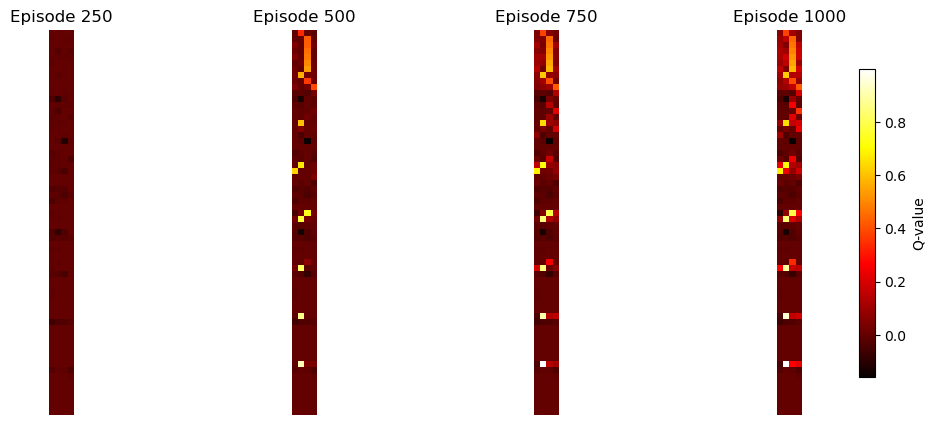

In [11]:
# Compute global min and max across all Q snapshots
vmin = min(q.min() for q in q_values_at_intervals)
vmax = max(q.max() for q in q_values_at_intervals)

fig, ax = plt.subplots(1, len(q_values_at_intervals), figsize=(15, 5))

for i, q_values in enumerate(q_values_at_intervals):
    im = ax[i].imshow(q_values, cmap='hot', interpolation='nearest',
                      vmin=vmin, vmax=vmax)  # shared scale

    ax[i].set_title(f'Episode {(nEpisodes // 4) * (i + 1)}')
    ax[i].axis('off')

# One shared colorbar
cbar = fig.colorbar(im, ax=ax.ravel().tolist(), shrink=0.8)
cbar.set_label("Q-value")

plt.show()

## Q-Table Evolution

This plot shows how Q-values change over time.

### What can we learn?

- Q-values start low and increase for some state-action pairs  
- Higher values mean: “this action often leads to good outcomes”

🟡 Which states do you expect to have high Q-values?

---

### Why is this confusing?

- The Q-table is a flat matrix  
- But the environment is a **2D grid**

So we see:
> values changing  

But not:
> what the agent actually *does*

---

### Better ways to show learning

- $\text{mean}(Q)$ → plot the average of $Q$ as the learning progress  

---

### Key takeaway

- Q-values = internal estimates  
- Policy = actual behavior  

Next, we visualize the **policy on the map**

## Visualizing What the Agent Learned

The Q-table is hard to interpret directly because:
- States are stored as flat indices (0 → 63)
- But the environment is actually a **2D grid**

So we will:

### 1. Policy Map (Best Action)
- Show the **best action per state**
- Represented as arrows:
  - ← LEFT
  - ↓ DOWN
  - → RIGHT
  - ↑ UP

### 2. Q-Value Maps (Per Action)
- Show **how good each action is**
- One heatmap per action

This makes learning **spatial and intuitive**.

In [8]:
def plot_policy_on_map(Q, env):
    """Overlay learned policy on the actual map"""
    desc = env.unwrapped.desc.astype(str)
    map_size = desc.shape[0]

    Q_grid = Q.reshape(map_size, map_size, -1)
    policy = np.argmax(Q_grid, axis=2)

    action_symbols = {
        0: "←",
        1: "↓",
        2: "→",
        3: "↑"
    }

    color_map = {
        'S': 0.8,
        'F': 0.6,
        'H': 0.0,
        'G': 1.0
    }

    grid = np.vectorize(color_map.get)(desc)

    plt.figure(figsize=(6, 6))
    plt.imshow(grid)

    for i in range(map_size):
        for j in range(map_size):
            tile = desc[i, j]

            if tile in ['H', 'G']:
                # Show tile type
                plt.text(j, i, tile,
                         ha='center', va='center', fontsize=12, color='red')
            else:
                action = policy[i, j]
                plt.text(j, i, action_symbols[action],
                         ha='center', va='center', fontsize=14)

    plt.title("Policy on FrozenLake Map")
    plt.xticks([])
    plt.yticks([])
    plt.grid()
    plt.show()

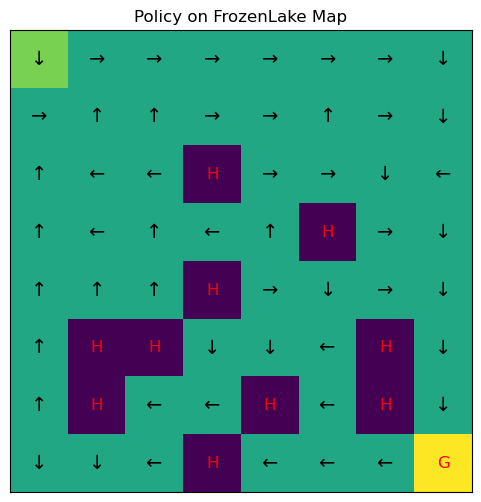

In [9]:
plot_policy_on_map(Q, env)

## 🟡 What Did the Agent Learn?

Look at the arrows:

- Does the agent avoid holes?
- Does it take the shortest path?
- Are there any strange decisions?
- Is the quality of decisons the same everywhere?

If yes, why might that happen?

# 🟡 Question
Try breaking the algorithm by gradually changing the epsilon from 0 to 1, before doing that, predict what you expect to see, after the experiemtn check if those expectations happened.